# Fixed points in the GLV system
The system
$$
\dot{x}_i = x_i \left(1- x_i + \sum_j A_{ij}\alpha_{ij}x_j\right)
$$

always admits $x = 0$ as a fixed point.
The other fixed point is given by:
$$
1-x_i^* + \sum_j A_{ij}\alpha_{ij}x_j^* = 0 \\
x_i^* = 1 + \sum_j W_{ij} x_j^*
$$
that in vectorial form results in:
$$
x^* = (1-W)^{-1}1
$$
thus when the matrix $(1-W)$ is not invertible the surviving species explode to infinity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glv

In [2]:
N = 1000
C = 50      
mu = -0.5   
sigma = 0.5  

In [3]:
degrees = np.round(np.random.exponential(scale=C, size=N)).astype(int)
if np.sum(degrees) % 2 != 0:
    degrees[0] += 1

M = glv.generate_matrix(degrees, C, mu=mu, sigma=sigma)

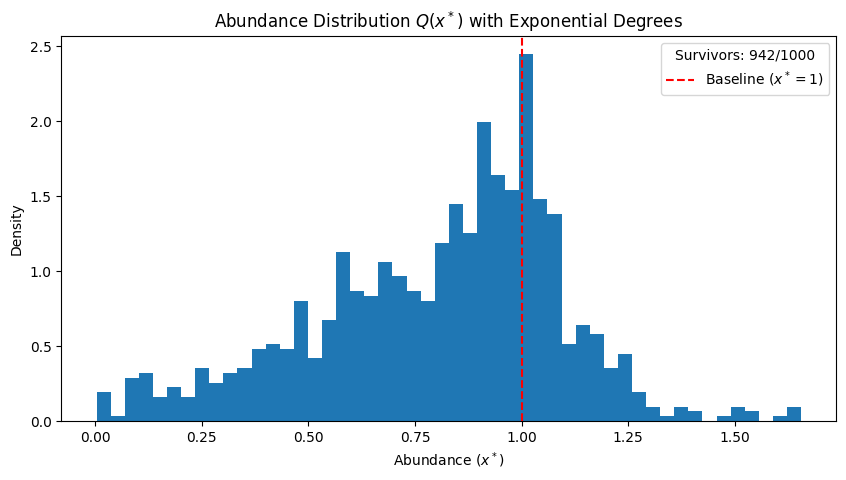

In [12]:
steady_state = glv.fixed_point(M)
survivors = steady_state[steady_state > 0]

plt.figure(figsize=(10, 5))
# Plotting the abundance distribution Q(x*) 
plt.hist(survivors, bins=50, density=True)
plt.axvline(1.0, color='red', linestyle='--', label='Baseline ($x^*=1$)')
plt.title(r"Abundance Distribution $Q(x^*)$ with Exponential Degrees")
plt.xlabel("Abundance ($x^*$)")
plt.ylabel("Density")
plt.legend(title=f"Survivors: {len(survivors)}/{N}")
plt.show()